### Lab 5.2: Convolutional Neural Networks in PyTorch

In this lab you will explore how to create a convolutional neural network (CNN) with PyTorch.

The CNN will run slowly unless you have an accelerator (like on newer MacBooks or in Google Colab).  On Colab, make sure to select a GPU runtime in `Runtime > Change runtime type` (T4 is sufficient).

This code will select the correct accelerator device based on your hardware.

In [8]:
import torch
device = 'cuda'

To get Torch to use the accelerator, we need to explictly move our data and computations to the device, and back when we are done.  Here's an example:

In [9]:
from torch import nn
x = torch.zeros(1).to(device)
lin = nn.Linear(1,3).to(device)
y = lin(x)
y.cpu()

tensor([-0.7306,  0.8605, -0.3473], grad_fn=<ToCopyBackward0>)

If you need get a scalar from the device, you can use `.item()`:

In [10]:
y[0].item()

-0.7305680513381958

Now let's get a dataset together.  Here I load the Intel Image Classification dataset.  The images have been resized to 32x32.

In [11]:
!wget -q -nc -O intel_image_classification.npz "https://www.dropbox.com/scl/fi/g8piaiw6njhogb7fnu7b3/intel_image_classification.npz?rlkey=8ytc0ucpc7tg2gzs0gxtnzun5&dl=1"

In [12]:
import numpy as np
from matplotlib import pyplot as plt

In [13]:
data = np.load('intel_image_classification.npz')
label_names = data['label_names']
X_train = data['X_train']
y_train = data['y_train']
X_test = data['X_test']
y_test = data['y_test']

The dataset has six categories and around 16k images total.

In [14]:
label_names

array(['buildings', 'forest', 'glacier', 'mountain', 'sea', 'street'],
      dtype='<U9')

In [15]:
X_train.shape, X_train.dtype, X_train.min(), X_train.max()

((13986, 32, 32, 3), dtype('float32'), np.float32(0.0), np.float32(1.0))

In [16]:
y_train.shape, y_train.dtype, y_train.min(), y_train.max()

((13986,), dtype('int64'), np.int64(0), np.int64(5))

In [17]:
len(X_train), len(X_test)

(13986, 2993)

Text(0.5, 1.0, '0')

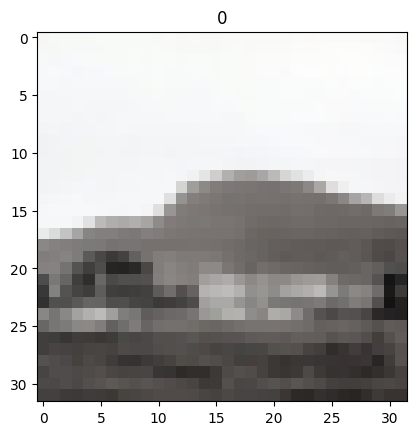

In [18]:
plt.imshow(X_train[0])
plt.title(y_train[0])

In [19]:
import torch
import torch.nn as nn
from torch.utils.data import TensorDataset, DataLoader

In [20]:
X_train_torch = torch.tensor(X_train.transpose((0,3,1,2))) # change dim ordering for PyTorch
y_train_torch = torch.tensor(y_train)
X_test_torch = torch.tensor(X_test.transpose((0,3,1,2))) # change dim ordering for PyTorch
y_test_torch = torch.tensor(y_test)

## Exercises

Create a CNN to classify the images.  Here is a starting point for your architecture, although you are free to put whatever you want into the network:

* Input layer
* 2D convolution, 3x3 kernel, 32 channels, ReLU activation
* Max pooling: 2x2 kernel, stride of 2
* 2D convolution, 3x3 kernel, 64 channels, ReLU activation
* Max pooling: 2x2 kernel, stride of 2
* 2D convolution, 3x3 kernel, 128 channels, ReLU activation
* Max pooling: 2x2 kernel, stride of 2
* Flatten
* Linear layer: 6 outputs

Choose some settings for the optimizer etc. and see what accuracy can you achieve on this dataset.

*Important:* Make sure to do

    model = model.to(device)

to move your model to the accelerator.  Also, in your training loop, be sure to move your data batches to the accelerator using, for example:

    x_batch = x_batch.to(device)
    y_batch = y_batch.to(device)





In [22]:
# YOUR CODE GOES HERE
train_loader = DataLoader(TensorDataset(X_train_torch, y_train_torch), batch_size=128, shuffle=True)
test_loader = DataLoader(TensorDataset(X_test_torch, y_test_torch), batch_size=256)

model = nn.Sequential(
    nn.Conv2d(3, 32, 3, padding=1), nn.ReLU(), nn.MaxPool2d(2, 2),
    nn.Conv2d(32, 64, 3, padding=1), nn.ReLU(), nn.MaxPool2d(2, 2),
    nn.Conv2d(64, 128, 3, padding=1), nn.ReLU(), nn.MaxPool2d(2, 2),
    nn.Flatten(),
    nn.Linear(128 * 4 * 4, 6),
).to(device)

loss_fn = nn.CrossEntropyLoss()
optimizer = torch.optim.Adam(model.parameters(), lr=1e-3)

def evaluate(loader):
    model.eval()
    correct = 0
    with torch.no_grad():
        for x, y in loader:
            x, y = x.to(device), y.to(device)
            correct += (model(x).argmax(1) == y).sum().item()
    return correct / len(loader.dataset)

for epoch in range(15):
    model.train()
    total_loss = 0
    for x, y in train_loader:
        x, y = x.to(device), y.to(device)
        optimizer.zero_grad()
        loss = loss_fn(model(x), y)
        loss.backward()
        optimizer.step()
        total_loss += loss.item() * len(x)
    print(f'epoch {epoch+1:2d}  loss {total_loss/len(train_loader.dataset):.4f}  '
          f'train acc {evaluate(train_loader):.3f}  test acc {evaluate(test_loader):.3f}')

epoch  1  loss 1.2147  train acc 0.651  test acc 0.642
epoch  2  loss 0.9033  train acc 0.692  test acc 0.677
epoch  3  loss 0.7980  train acc 0.688  test acc 0.675
epoch  4  loss 0.7568  train acc 0.730  test acc 0.708
epoch  5  loss 0.7000  train acc 0.734  test acc 0.704
epoch  6  loss 0.6672  train acc 0.777  test acc 0.755
epoch  7  loss 0.6417  train acc 0.781  test acc 0.758
epoch  8  loss 0.6181  train acc 0.789  test acc 0.760
epoch  9  loss 0.5997  train acc 0.778  test acc 0.742
epoch 10  loss 0.5615  train acc 0.791  test acc 0.755
epoch 11  loss 0.5487  train acc 0.820  test acc 0.780
epoch 12  loss 0.5315  train acc 0.826  test acc 0.771
epoch 13  loss 0.5089  train acc 0.817  test acc 0.784
epoch 14  loss 0.5008  train acc 0.839  test acc 0.777
epoch 15  loss 0.4907  train acc 0.843  test acc 0.785


Trying to change up the architecture to improve accuarcy.

*   Adding a second Conv2d to each layer
*   Adding nn.BatchNorm2d(...) before each ReLU



In [25]:
train_loader = DataLoader(TensorDataset(X_train_torch, y_train_torch), batch_size=128, shuffle=True)
test_loader = DataLoader(TensorDataset(X_test_torch, y_test_torch), batch_size=256)

def conv_bn_relu(in_ch, out_ch):
    return [nn.Conv2d(in_ch, out_ch, 3, padding=1, bias=False), nn.BatchNorm2d(out_ch), nn.ReLU()]

def block(in_ch, out_ch):
    return nn.Sequential(*conv_bn_relu(in_ch, out_ch), *conv_bn_relu(out_ch, out_ch), nn.MaxPool2d(2, 2))

model = nn.Sequential(
    block(3, 32),
    block(32, 64),
    block(64, 128),
    nn.Flatten(),
    nn.Linear(128 * 4 * 4, 6),
).to(device)

loss_fn = nn.CrossEntropyLoss()
optimizer = torch.optim.Adam(model.parameters(), lr=1e-3)

def evaluate(loader):
    model.eval()
    correct = 0
    with torch.no_grad():
        for x, y in loader:
            x, y = x.to(device), y.to(device)
            correct += (model(x).argmax(1) == y).sum().item()
    return correct / len(loader.dataset)

for epoch in range(50):
    model.train()
    total_loss = 0
    for x, y in train_loader:
        x, y = x.to(device), y.to(device)
        optimizer.zero_grad()
        loss = loss_fn(model(x), y)
        loss.backward()
        optimizer.step()
        total_loss += loss.item() * len(x)
    print(f'epoch {epoch+1:2d}  loss {total_loss/len(train_loader.dataset):.4f}  '
          f'train acc {evaluate(train_loader):.3f}  test acc {evaluate(test_loader):.3f}')

epoch  1  loss 0.9067  train acc 0.517  test acc 0.513
epoch  2  loss 0.6446  train acc 0.647  test acc 0.628
epoch  3  loss 0.5478  train acc 0.822  test acc 0.790
epoch  4  loss 0.4544  train acc 0.839  test acc 0.799
epoch  5  loss 0.4179  train acc 0.875  test acc 0.816
epoch  6  loss 0.3764  train acc 0.826  test acc 0.770
epoch  7  loss 0.3334  train acc 0.878  test acc 0.803
epoch  8  loss 0.2941  train acc 0.879  test acc 0.814
epoch  9  loss 0.2687  train acc 0.925  test acc 0.834
epoch 10  loss 0.2180  train acc 0.946  test acc 0.837
epoch 11  loss 0.1854  train acc 0.873  test acc 0.768
epoch 12  loss 0.1432  train acc 0.914  test acc 0.797
epoch 13  loss 0.1359  train acc 0.902  test acc 0.792
epoch 14  loss 0.0888  train acc 0.970  test acc 0.826
epoch 15  loss 0.0585  train acc 0.966  test acc 0.815
epoch 16  loss 0.0497  train acc 0.985  test acc 0.847
epoch 17  loss 0.0411  train acc 0.987  test acc 0.832
epoch 18  loss 0.0519  train acc 0.965  test acc 0.828
epoch 19  

Improved the training accuracy greatly, and increased the testing accuracy as well (although not as dramatically). Also tried adding more epochs, which seemed to just overfit the model due to the testing accuracy plateauing at about 0.83 and the training accuracy becoming nearly perfect.